## **Gradient Boosting Classifier**


## Import Libraries

In [ ]:
# ==========================================================
# Import Libraries
# ==========================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
   
)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [20]:
df = pd.read_csv('main_clean_data.csv')

In [21]:
df.head()

,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,...,education_background_Undergrad,education_background_WorkingPro,course_level_Advanced,course_level_Beginner,course_level_Intermediate,course_category_Business,course_category_Data,course_category_Design,course_category_Marketing,course_category_Programming
0,1.395524,-0.975477,-1.886282,-1.062757,-1.540257,-0.369750,-1.458420,-0.344933,-1.018644,-1.743625,...,1,0,0,0,1,1,0,0,0,0
1,-1.314686,0.493337,-0.213248,1.101746,-1.201238,-1.159715,1.706847,-0.344933,-1.153411,1.423907,...,1,0,0,0,1,0,0,0,0,1
2,0.130760,0.827158,-1.328604,-1.117974,-0.523201,-1.949681,-0.930876,-1.357553,-0.352295,-0.320531,...,0,0,1,0,0,0,0,0,0,1
3,0.311440,-1.109006,1.794392,0.538533,2.256752,0.815198,1.179302,-1.357553,-0.569420,0.276250,...,1,0,0,1,0,0,0,1,0,0
4,0.311440,-0.975477,0.455965,1.664958,1.171892,0.815198,-0.930876,-1.357553,-0.135170,-0.283806,...,0,1,1,0,0,1,0,0,0,0


# Features and Target


In [22]:
# ==========================================================
# Features and Target
# ==========================================================

X = df.drop('completion_status', axis=1)

y = df['completion_status']

##  Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [24]:
# ==========================================================
# Gradient Boosting Classifier
# ==========================================================

gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_clf.fit(
    X_train,
    y_train
)

y_pred = gb_clf.predict(
    X_test
)

## Gradient Boosting Accuracy 

In [25]:
# ==========================================================
# Accuracy Score
# ==========================================================

gb_acc = accuracy_score(
    y_test,
    y_pred
)

print(
    "Gradient Boosting Accuracy :",
    gb_acc
)

Gradient Boosting Accuracy : 0.8460661345496009


## Classification Report

In [26]:
# ==========================================================
# Classification Report
# ==========================================================

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88       564
         1.0       0.79      0.77      0.78       313

    accuracy                           0.85       877
   macro avg       0.83      0.83      0.83       877
weighted avg       0.85      0.85      0.85       877



## Confusion Matrix

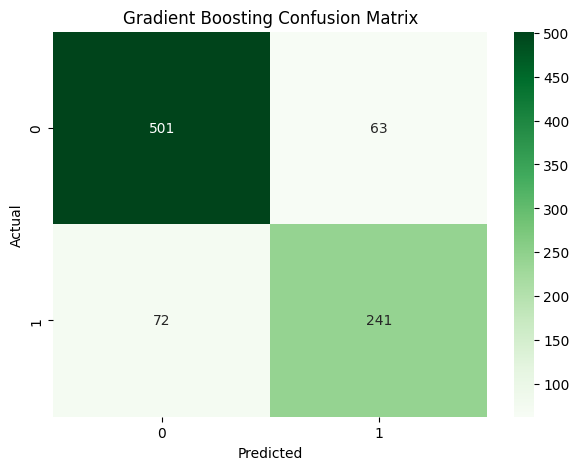

In [27]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "Gradient Boosting Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC AUC Score


In [28]:
# ==========================================================
# ROC AUC Score
# ==========================================================

from sklearn.metrics import roc_auc_score

# Probability for Positive Class
y_prob = gb_clf.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC Score :{auc_score:.4f}")

ROC-AUC Score :0.9176


# ROC Curve


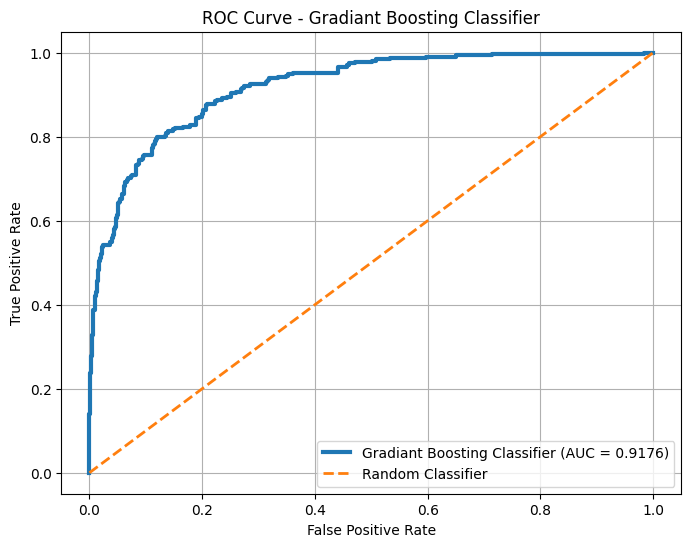

In [29]:
# ==========================================================
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'Gradiant Boosting Classifier (AUC = {auc_score:.4f})'
)

# Random Classifier Line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2,
    label='Random Classifier'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Gradiant Boosting Classifier"
)

plt.legend()

plt.grid(True)

plt.show()

## **Gradient Boosting Regressor**

## Import Libraries

In [30]:
# ==========================================================
# Import Libraries
# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Features and Target


In [31]:
# ==========================================================
# Features and Target
# ==========================================================

X = df.drop(
    'final_score',
    axis=1
)

y = df['final_score']

## Train Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [33]:
# ==========================================================
# Gradient Boosting Regressor
# ==========================================================

gb_reg = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_reg.fit(
    X_train,
    y_train
)

y_pred = gb_reg.predict(
    X_test
)

## Regression Metrics

In [34]:
# ==========================================================
# Evaluation Metrics
# ==========================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 6.3675872691823985
MSE : 62.27984669515134
RMSE : 7.891758149813724
R2 Score : 0.6379583309890476


# Actual vs Predicted


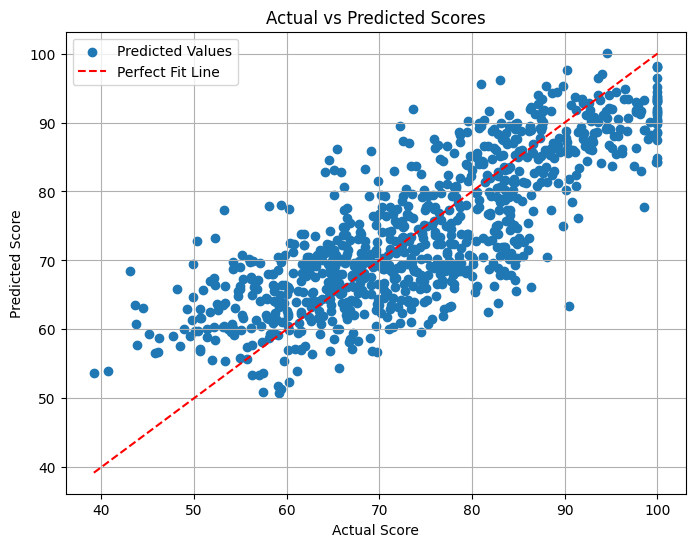

In [35]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    label="Predicted Values"
)

# Perfect Fit Line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Fit Line"
)

plt.xlabel("Actual Score")

plt.ylabel("Predicted Score")

plt.title("Actual vs Predicted Scores")

plt.legend()

plt.grid(True)

plt.show()

# Gradient Boosting Classifier Analysis

## Overview

Gradient Boosting is a powerful ensemble learning technique that builds models sequentially. Each new model attempts to correct the errors made by previous models, resulting in improved predictive performance. Unlike Bagging, which trains models independently, Gradient Boosting learns from previous mistakes and continuously improves the model.

In this project, Gradient Boosting Classifier was implemented to predict student course completion status.

---

## Classification Results

### Accuracy Score

**Accuracy = 84.61%**

The Gradient Boosting Classifier correctly predicted approximately 85 out of every 100 student completion outcomes.

---

## Classification Report

| Class | Precision | Recall | F1-Score |
|---------|---------|---------|---------|
| 0 (Not Completed) | 0.87 | 0.89 | 0.88 |
| 1 (Completed) | 0.79 | 0.77 | 0.78 |

### Macro Average

- Precision: 0.83
- Recall: 0.83
- F1-Score: 0.83

### Weighted Average

- Precision: 0.85
- Recall: 0.85
- F1-Score: 0.85

---

## Interpretation

- The model achieved strong classification performance across both classes.
- Students who did not complete the course were identified with high precision and recall.
- The completed class also showed balanced prediction performance.
- The F1-scores indicate good consistency between precision and recall.
- Gradient Boosting successfully reduced classification errors through sequential learning.

---

## ROC-AUC Analysis

### ROC-AUC Score

**ROC-AUC = 0.9176**

The Receiver Operating Characteristic Area Under the Curve (ROC-AUC) measures the model's ability to distinguish between completed and non-completed students.

### Interpretation

| AUC Score | Performance |
|------------|------------|
| 0.50 | Poor |
| 0.60 - 0.70 | Fair |
| 0.70 - 0.80 | Good |
| 0.80 - 0.90 | Very Good |
| Above 0.90 | Excellent |

The obtained ROC-AUC score of **0.9176** indicates excellent classification capability and strong class separation performance.

---

## Gradient Boosting Classifier Conclusion

The Gradient Boosting Classifier achieved an accuracy of **84.61%** with an excellent **ROC-AUC score of 0.9176**. The model effectively learned complex relationships within the dataset and demonstrated strong predictive performance. The high ROC-AUC score confirms the model's ability to accurately distinguish between students who completed the course and those who did not.

---

# Gradient Boosting Regressor Analysis

## Overview

Gradient Boosting Regressor applies boosting techniques to regression tasks by sequentially building trees that correct prediction errors from previous models. This approach enables the model to capture complex patterns and relationships within the data.

The objective was to predict student final scores based on academic and engagement-related features.

---

## Regression Results

| Metric | Value |
|----------|----------|
| MAE | 6.37 |
| MSE | 62.28 |
| RMSE | 7.89 |
| R² Score | 0.6380 |

---

### Mean Absolute Error (MAE)

**MAE = 6.37**

On average, the predicted score differs from the actual score by approximately 6.37 marks.

---

### Mean Squared Error (MSE)

**MSE = 62.28**

The average squared prediction error is relatively low, indicating strong prediction accuracy.

---

### Root Mean Squared Error (RMSE)

**RMSE = 7.89**

The model's predictions deviate from actual scores by approximately 7.89 marks on average.

---

### R² Score

**R² Score = 0.6380**

This indicates that approximately **63.80% of the variation in student final scores** is explained by the Gradient Boosting Regressor model.

---

## Interpretation

- The model captured a substantial portion of the relationship between features and final scores.
- Error values remained relatively low, indicating reliable predictions.
- The R² score demonstrates good explanatory power and predictive capability.
- Gradient Boosting improved prediction quality through iterative error correction.

---

## Gradient Boosting Regressor Conclusion

The Gradient Boosting Regressor achieved an **R² score of 0.6380**, indicating that the model explains approximately **63.80% of the variance** in student final scores. With an **MAE of 6.37** and **RMSE of 7.89**, the model produced accurate and reliable score predictions. The results demonstrate the effectiveness of Gradient Boosting for regression-based educational analytics.

---

# Final Gradient Boosting Summary

Gradient Boosting proved to be a highly effective ensemble learning technique for both classification and regression tasks.

### Classification Performance

- Accuracy: **84.61%**
- ROC-AUC Score: **0.9176**
- Weighted F1-Score: **0.85**

### Regression Performance

- R² Score: **63.80%**
- MAE: **6.37**
- RMSE: **7.89**

### Overall Conclusion

The Gradient Boosting model delivered strong predictive performance by sequentially correcting the errors of previous learners. The classifier achieved excellent discrimination capability with a high ROC-AUC score, while the regressor demonstrated strong predictive accuracy with low error values and a solid R² score. These results confirm that Gradient Boosting is a powerful ensemble learning technique for predicting student course completion status and final academic performance in the Smart Outcome Predictor project.